In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

In [43]:
# mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
# and the thrid group ： reference group
# get topn popular from spotify with 2000-2023,and then concat with the previous grammy_group use spotify_index,to make sure which one belong to both of them.
# then, groupby year to get every year average feature value. show the trend.
# also can use it to check the overlap between two groups

spotify= pd.read_csv('/content/drive/MyDrive/Data/spotify_data.csv')

In [45]:
# choose a suitable n
topn=100
# filter_col=['spotify_index','artist_name','track_name','popularity','year','danceability','valence']
spotify.columns

Index(['Unnamed: 0', 'artist_name', 'track_name', 'track_id', 'popularity',
       'year', 'genre', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature'],
      dtype='object')

In [46]:
print(np.sort(spotify['year'].unique()))

[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023]


In [47]:
spotify.rename(columns={'Unnamed: 0':'spotify_index'}, inplace=True)

In [48]:
# sort and groupby year and get topn
spotify_group = spotify.sort_values(by=['year','popularity'], ascending=[True,False]).groupby('year').head(topn).reset_index(drop=True)

In [49]:
# show records count
len(spotify_group)

2400

In [50]:
# take a look
spotify_group.head(20)

,spotify_index,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,651395,Eminem,The Real Slim Shady,3yfqSUWxFvZELEM4PmlwIR,86,2000,hip-hop,0.949,0.661,5,-4.244,0,0.0572,0.03020,0.000000,0.0454,0.760,104.504,284200,4
1,651397,Eminem,Stan,3UmaczJpikHgJFyBTAJVoz,82,2000,hip-hop,0.780,0.768,6,-4.325,0,0.2380,0.03710,0.000002,0.5180,0.507,80.063,404107,4
2,651396,Outkast,Ms. Jackson,0I3q5fE6wg7LIfHGngUTnV,80,2000,hip-hop,0.843,0.806,4,-5.946,0,0.2690,0.14300,0.000000,0.0771,0.613,94.948,270507,4
3,631350,Shaggy,It Wasn't Me,3WkibOpDF7cQ5xntM1epyf,77,2000,dance,0.853,0.606,0,-4.596,1,0.0713,0.05610,0.000000,0.3130,0.654,94.759,227600,4
4,631352,Britney Spears,Oops!...I Did It Again,6naxalmIoLFWR0siv8dnQQ,77,2000,dance,0.751,0.834,1,-5.444,0,0.0437,0.30000,0.000018,0.3550,0.894,95.053,211160,4
5,623702,Toploader,Dancing in the Moonlight,3Fzlg5r1IjhLk2qRw667od,76,2000,alt-rock,0.632,0.856,10,-3.463,1,0.0348,0.06240,0.000000,0.3470,0.867,119.397,232693,4
6,642617,Limp Bizkit,Rollin' (Air Raid Vehicle),3IV4swNduIRunHREK80owz,75,2000,funk,0.603,0.933,1,-3.358,1,0.1710,0.00591,0.000000,0.2060,0.709,96.306,213760,4
7,631354,Shaggy,Angel,7FDV5ELOJHCGLe52AnttEd,74,2000,dance,0.740,0.766,6,-2.939,1,0.1780,0.11600,0.000000,0.0406,0.807,170.531,235133,4
8,651400,Eminem,The Way I Am,23wfXwnsPZYe5A1xXRHb3J,73,2000,hip-hop,0.785,0.871,4,-2.692,0,0.2650,0.14400,0.000000,0.3090,0.315,87.248,290427,4
9,662658,Juan Gabriel,Abrázame Muy Fuerte,2nejvFyJeTDtMRP2nUMt0J,72,2000,pop,0.515,0.387,4,-7.343,0,0.0567,0.68900,0.000000,0.1260,0.312,135.739,239427,4


In [51]:
# load the grammy_group
grammy_group= pd.read_csv('/content/drive/MyDrive/Data/grammy_group.csv')

In [52]:
grammy_group.columns
filter_grammy_group=grammy_group[['grammy_index', 'grammy_year', 'annual_edition', 'category', 'artist',
       'producers', 'song_or_album', 'winner', 'url', 'spotify_index']]

In [53]:
spotify_group.columns

Index(['spotify_index', 'artist_name', 'track_name', 'track_id', 'popularity',
       'year', 'genre', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature'],
      dtype='object')

In [54]:
# merge them with spotify_index
spotify_group_merged=pd.merge(spotify_group,filter_grammy_group,how='left',on=['spotify_index'],indicator=True)

In [55]:
spotify_group_merged.columns

Index(['spotify_index', 'artist_name', 'track_name', 'track_id', 'popularity',
       'year', 'genre', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'grammy_index',
       'grammy_year', 'annual_edition', 'category', 'artist', 'producers',
       'song_or_album', 'winner', 'url', '_merge'],
      dtype='object')

In [56]:
# we find that numbers of them are overlap
overlap_song=spotify_group_merged[spotify_group_merged['_merge']=='both']
len(overlap_song)

74

In [57]:
# put into file
spotify_group_merged
spotify_group_merged.to_csv('/content/drive/MyDrive/Data/spotify_group.csv',index=False)

In [58]:
# below are some experiments and visualizations
col=['popularity','danceability','valence']
mean_col= spotify_group_merged.groupby('year')[col].mean()
mean_col

,popularity,danceability,valence
year,,,
2000,66.08,0.627100,0.603640
2001,67.87,0.625660,0.533901
2002,67.96,0.592429,0.530595
2003,67.09,0.625020,0.582230
2004,68.94,0.643190,0.608744
2005,69.49,0.639440,0.560917
2006,69.49,0.613080,0.560200
2007,68.06,0.613460,0.557608
2008,69.44,0.625090,0.535077


<Axes: xlabel='year', ylabel='danceability'>

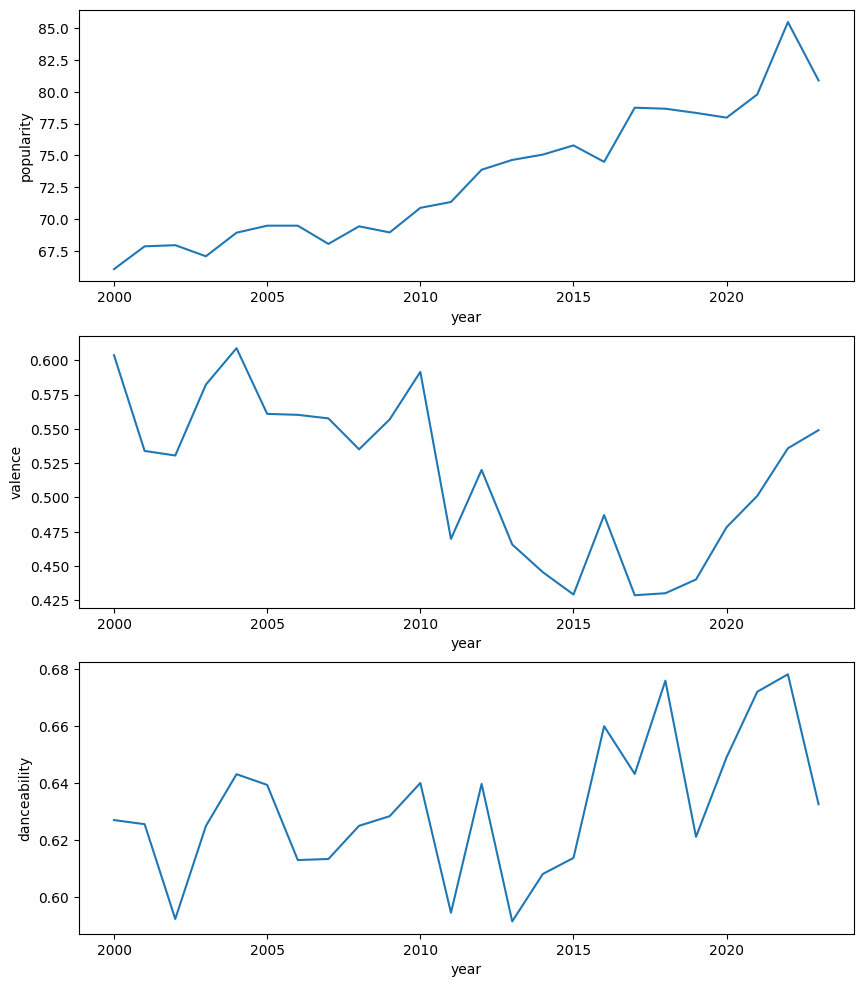

In [59]:
# plot with three features in spotify_group (popularity valence danceability)
plt.figure(figsize = (10,12))
plt.subplot(311)
sns.lineplot(x='year', y='popularity', data=mean_col)
plt.subplot(312)
sns.lineplot(x='year', y='valence', data=mean_col)
plt.subplot(313)
sns.lineplot(x='year', y='danceability', data=mean_col)
# 可以考虑看其他属性 有没有趋势


<Axes: xlabel='year', ylabel='danceability'>

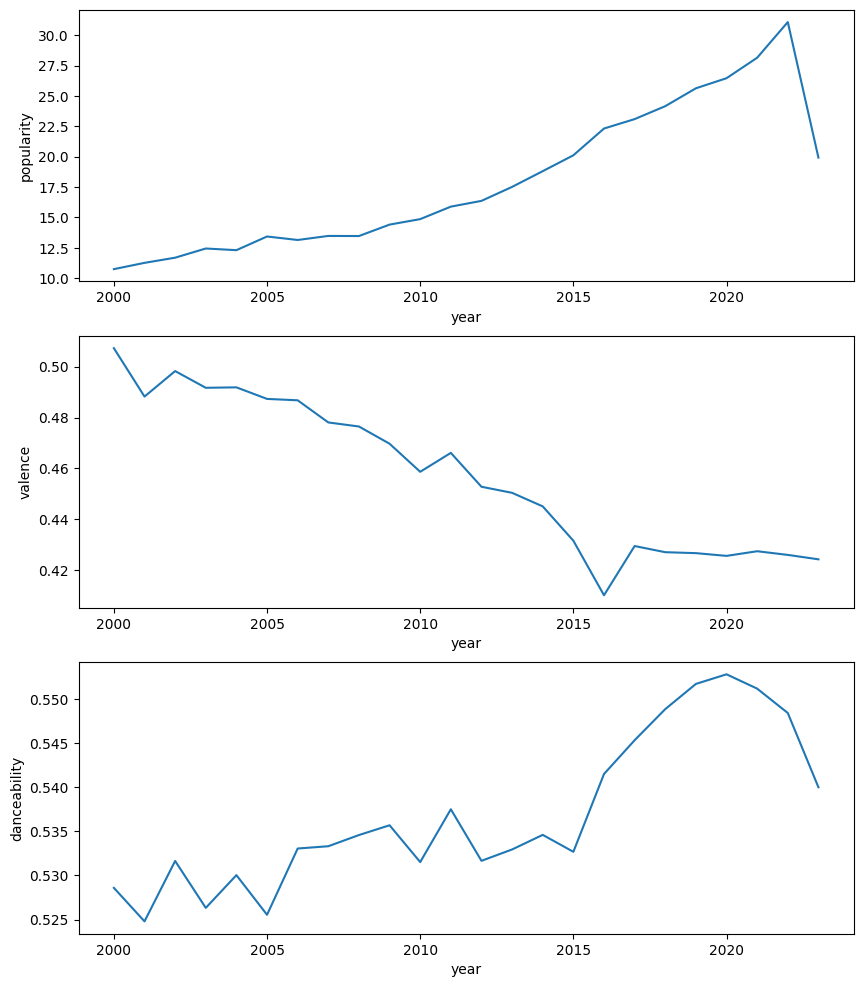

In [60]:
# show the same things with whole spotify
mean_col_all= spotify.groupby('year')[col].mean()
plt.figure(figsize = (10,12))
plt.subplot(311)
sns.lineplot(x='year', y='popularity', data=mean_col_all)
plt.subplot(312)
sns.lineplot(x='year', y='valence', data=mean_col_all)
plt.subplot(313)
sns.lineplot(x='year', y='danceability', data=mean_col_all)


<Axes: xlabel='spotify_year', ylabel='danceability'>

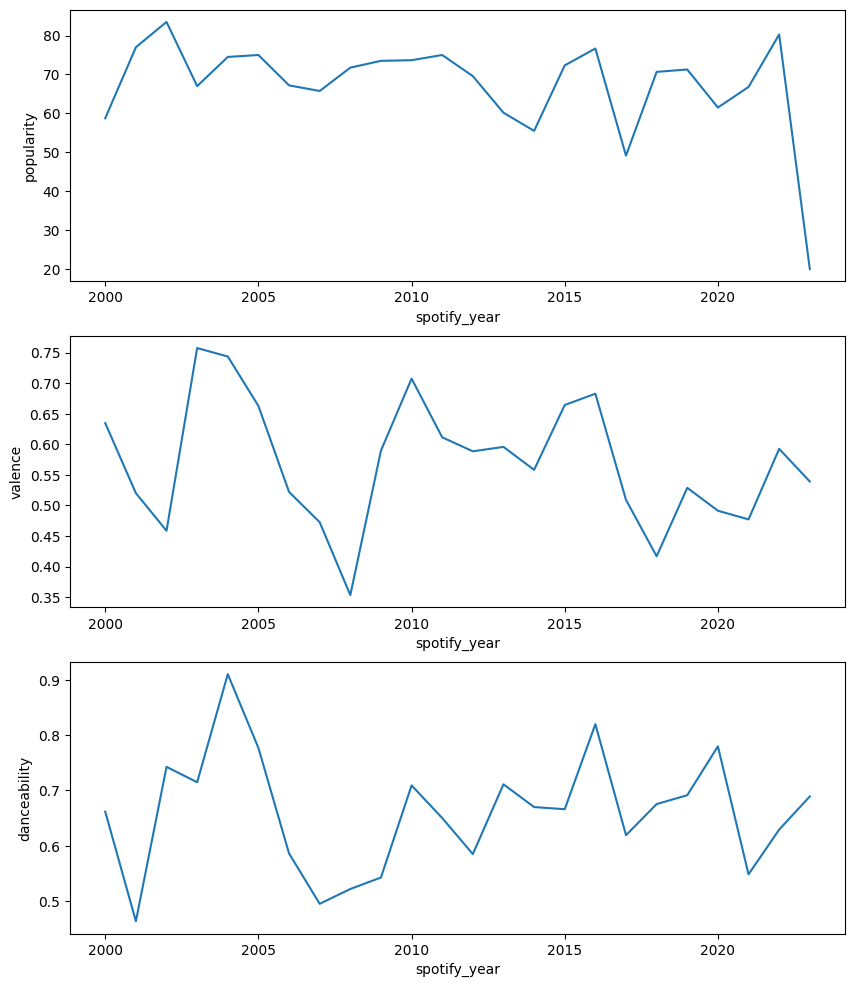

In [61]:
# show the same thing with grammy_group
mean_col_grammy= grammy_group.groupby('spotify_year')[col].mean()
plt.figure(figsize = (10,12))
plt.subplot(311)
sns.lineplot(x='spotify_year', y='popularity', data=mean_col_grammy)
plt.subplot(312)
sns.lineplot(x='spotify_year', y='valence', data=mean_col_grammy)
plt.subplot(313)
sns.lineplot(x='spotify_year', y='danceability', data=mean_col_grammy)

In [62]:
spotify_general_group=pd.read_csv('/content/drive/MyDrive/Data/spotify_data.csv')
grammy_group=pd.read_csv('/content/drive/MyDrive/Data/grammy_group.csv')
spotify_popular_group=pd.read_csv('/content/drive/MyDrive/Data/spotify_group.csv')

In [63]:
spotify_popular_group.columns

Index(['spotify_index', 'artist_name', 'track_name', 'track_id', 'popularity',
       'year', 'genre', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'grammy_index',
       'grammy_year', 'annual_edition', 'category', 'artist', 'producers',
       'song_or_album', 'winner', 'url', '_merge'],
      dtype='object')

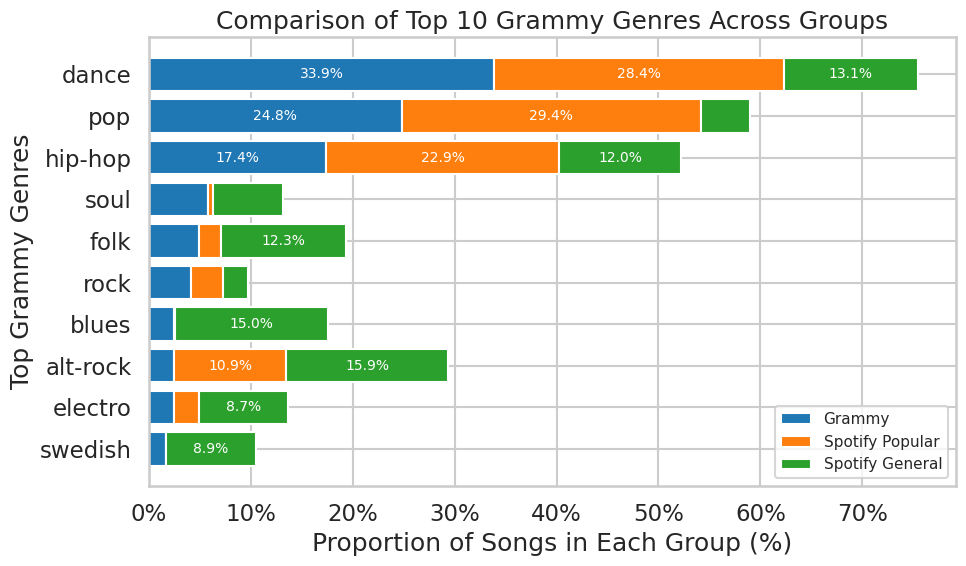

In [64]:
# plot the staked bar chart
sns.set_style("whitegrid")
sns.set_context("talk")

def plot_topn_grammy_genres(grammy, popular, general, topn=7):
    # get top genres from grammy
    grammy_counts = grammy['genre'].value_counts().head(topn)
    top_genres = grammy_counts.sort_values(ascending=True).index.tolist()

    # calculate ratio per group
    def get_ratio(df):
        counts = df[df['genre'].isin(top_genres)]['genre'].value_counts()
        ratio = (counts / counts.sum()).reindex(top_genres, fill_value=0)
        return ratio.tolist()

    grammy_ratio = get_ratio(grammy)
    popular_ratio = get_ratio(popular)
    general_ratio = get_ratio(general)

    # plot
    plt.figure(figsize=(10,6))
    colors = ['#1f77b4','#ff7f0e','#2ca02c']
    bottoms = [0]*topn

    for vals, color, label in zip([grammy_ratio, popular_ratio, general_ratio],
                                  colors,
                                  ['Grammy','Spotify Popular','Spotify General']):
        plt.barh(top_genres, vals, left=bottoms, color=color, label=label)
        # show value on bar
        for i, v in enumerate(vals):
            if v >= 0.07:
                plt.text(bottoms[i]+v/2, i, f"{v*100:.1f}%", ha='center', va='center', color='white', fontsize=10)
        bottoms = [b+v for b,v in zip(bottoms, vals)]

    plt.xlabel("Proportion of Songs in Each Group (%)")
    plt.ylabel("Top Grammy Genres")
    plt.title(f'Comparison of Top {topn} Grammy Genres Across Groups')
    plt.gca().xaxis.set_major_formatter(lambda x, _: f"{int(x*100)}%")
    plt.legend(fontsize=11, title_fontsize=12)
    plt.tight_layout()
    plt.show()


plot_topn_grammy_genres(grammy_group, spotify_popular_group, spotify_general_group, topn=10)

In [65]:
# get 3 groups mean and median value by year
target_feature=['popularity', 'danceability', 'energy','speechiness',
        'acousticness', 'instrumentalness', 'liveness','valence', 'duration_ms']
spotify_popular_data_mean= spotify_popular_group.groupby('year')[target_feature].mean()
spotify_popular_data_median= spotify_popular_group.groupby('year')[target_feature].median()
grammy_data_mean= grammy_group.groupby('spotify_year')[target_feature].mean()
grammy_data_median= grammy_group.groupby('spotify_year')[target_feature].median()
spotify_general_data_mean= spotify_general_group.groupby('year')[target_feature].mean()
spotify_general_data_median= spotify_general_group.groupby('year')[target_feature].mean()

In [66]:
# draw lineplot compare three groups in  given feature mean or median value per year
sns.set_style("whitegrid")
sns.set_context("talk")

def plot_feature(stat_type, feature):
    plt.figure(figsize=(12,5))

    if stat_type == 'Mean':
        grammy_df = grammy_data_mean
        pop_df = spotify_popular_data_mean
        general_df = spotify_general_data_mean
    else:
        grammy_df = grammy_data_median
        pop_df = spotify_popular_data_median
        general_df = spotify_general_data_median

    sns.lineplot(x='spotify_year', y=feature, data=grammy_df,
                 label='Critically Acclaimed',linewidth=2.5, marker='o')
    sns.lineplot(x='year', y=feature, data=pop_df,
                 label='Listener Hit',linewidth=2.5, marker='s')
    sns.lineplot(x='year', y=feature, data=general_df,
                 label='General Population',linewidth=2.5, marker='^')

    plt.xlabel('Year', fontsize=14)
    plt.ylabel(feature, fontsize=14)
    plt.title(f'{stat_type} of {feature} per Year (2000-2023)', fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.7)
    years = sorted(grammy_group['spotify_year'].unique())
    plt.xticks(years, rotation=45)
    plt.legend(fontsize=9, loc='best')
    plt.tight_layout()
    plt.show()


stat_widget = widgets.Dropdown(
    options=['Mean', 'Median'],
    value='Mean',
    description='Statistic:',
    style={'description_width': '120px'}
)

feature_widget = widgets.Dropdown(
    options=target_feature,value='valence',
    description='Feature:',
    style={'description_width': '120px'}
)

widgets.interact(
    plot_feature,
    stat_type=stat_widget,
    feature=feature_widget
)


interactive(children=(Dropdown(description='Statistic:', options=('Mean', 'Median'), style=DescriptionStyle(de…

<function __main__.plot_feature(stat_type, feature)>